In [8]:
from pathlib import Path

# Get project root
PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd()

# If running from notebooks/, go up one level
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RIPPLE_DIR = DATA_DIR / "mvripfft"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RIPPLE_DIR exists: {RIPPLE_DIR.exists()}")

PROJECT_ROOT: /root/JHU-LCAP/PyGaborSTM
RIPPLE_DIR exists: True


In [2]:
import sys

sys.path.insert(0, "..")

import re
import librosa
import matplotlib.pyplot as plt
import pygaborstm as stm
from pygaborstm.analysis import (
    plot_mtf_contour,
    plot_mtf_heatmap,
    plot_mtf_lines,
    plot_mtf_1d,
)

print(f"PyGaborSTM version: {stm.__version__}")

PyGaborSTM version: 0.1.0


/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [3]:
import numpy as np

extended_rates = np.array(
    [-128, -64, -32, -16, -8, -4, -2, -1, 1, 2, 4, 8, 16, 32, 64, 128]
)

config = stm.Config(n_filters=256, frmlen_ms=4.0, rates=extended_rates)
model = stm.PyGaborSTM(config=config)

rsf_dict = {}
for ripple_path in sorted(RIPPLE_DIR.glob("ripple_*.wav")):
    match = re.search(r"R(-?\d+\.?\d*)_S(\d+\.?\d*)", ripple_path.name)
    rate = float(match.group(1))
    scale = float(match.group(2))
    audio, _ = librosa.load(ripple_path, sr=16000)
    rsf = model.rsf(model.spectrogram(audio))
    rsf_dict[(rate, scale)] = rsf

print(f"Loaded {len(rsf_dict)} ripples")

Loaded 96 ripples


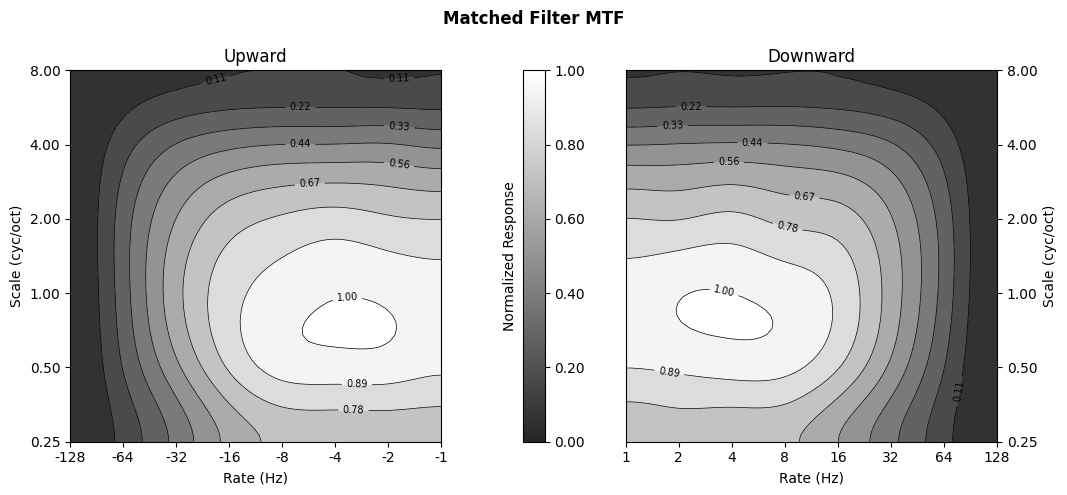

In [4]:
# Contour plot (Chi et al. style)
fig, axes = plot_mtf_contour(rsf_dict)
plt.show()

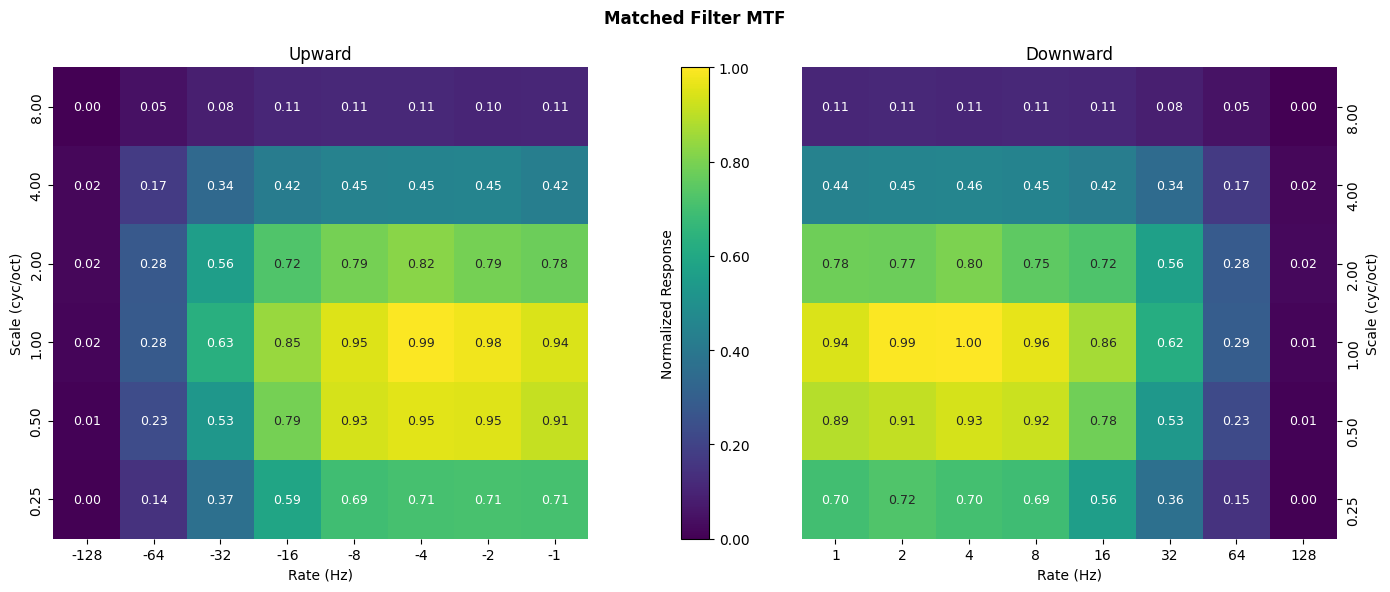

In [5]:
# Heatmap (seaborn style)
fig, axes = plot_mtf_heatmap(rsf_dict)
plt.show()

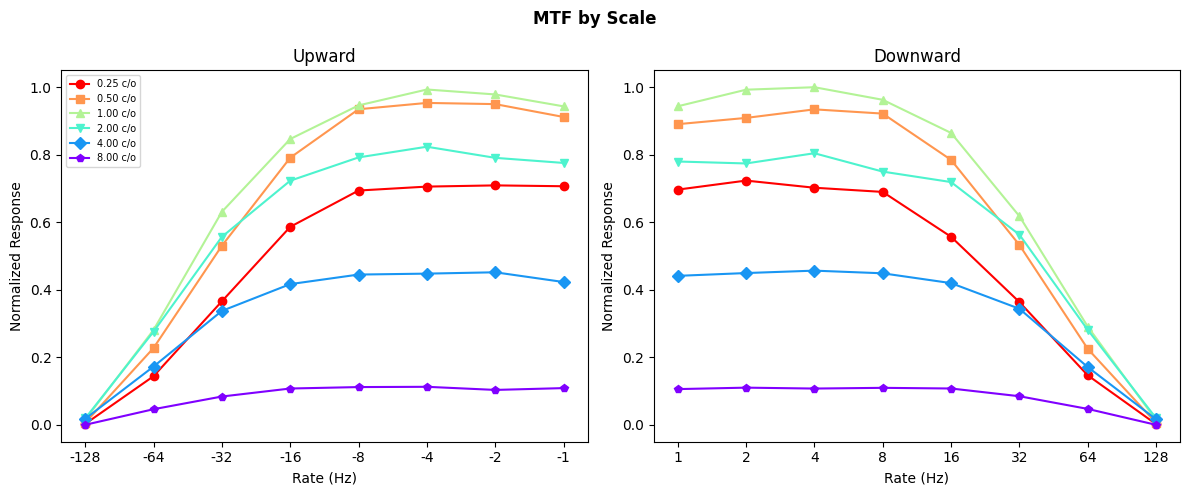

In [6]:
# Lines by scale
fig, axes = plot_mtf_lines(rsf_dict)
plt.show()

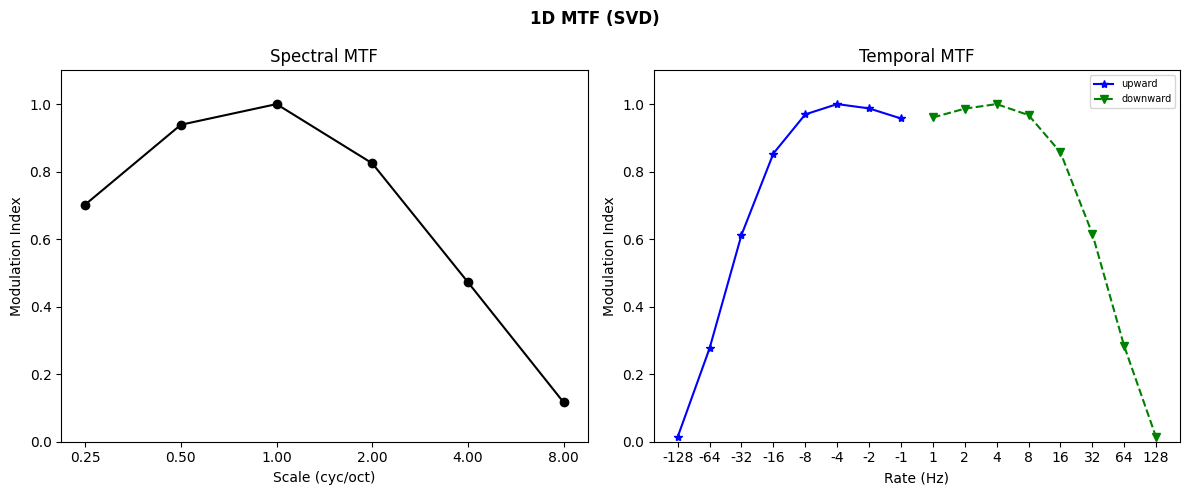

In [7]:
# 1D MTFs (SVD decomposition)
fig, axes = plot_mtf_1d(rsf_dict)
plt.show()